In [1]:
import os

os.chdir('..')

In [3]:
import os
import numpy as np

# Zmiana katalogu roboczego na wyższy (tak jak chciałeś)

# Poprawne wczytanie – podajesz bezpośrednio ścieżkę do np.load
with np.load("data/tiny_nerf_data.npz") as data:
    # Wyświetlamy klucze, żebyś wiedział, co jest w środku (np. 'images', 'poses', 'focal')
    print("Zawartość pliku:", data.files) 
    
    # Przykładowe wyciągnięcie danych (zmień nazwy kluczy na te z Twojego pliku)
    images = data['images']
    poses = data['poses']
    focal = data['focal']

Zawartość pliku: ['images', 'poses', 'focal']


Zdjęcia: (106, 100, 100, 3)
Pozycje: (106, 4, 4)
Ogniskowa (focal): 138.89


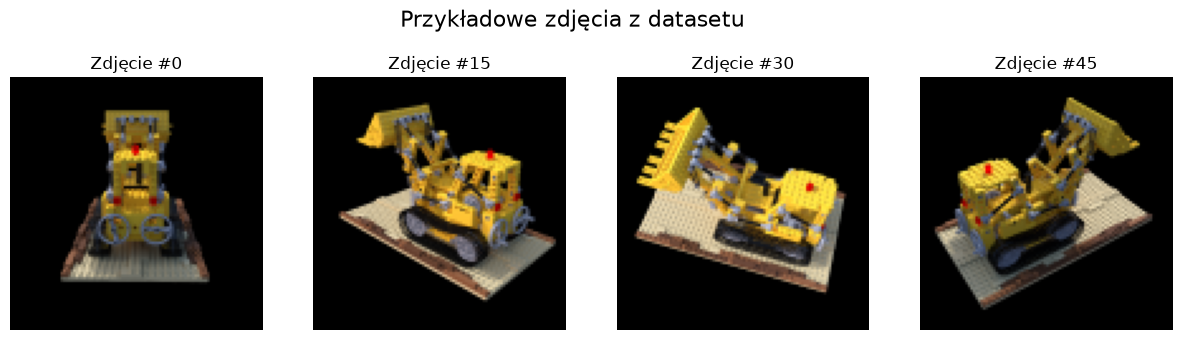

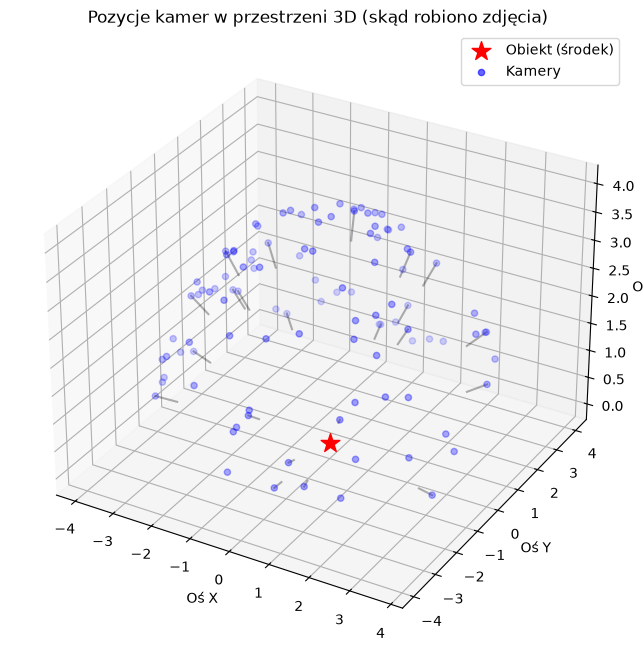

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Wczytanie danych (zakładamy, że jesteś już w katalogu głównym repo)
with np.load("data/tiny_nerf_data.npz") as data:
    images = data['images']
    poses = data['poses']
    focal = data['focal']

print(f"Zdjęcia: {images.shape}")  # (N, H, W, 3) -> N zdjęć o wymiarach HxW z 3 kanałami RGB
print(f"Pozycje: {poses.shape}")   # (N, 4, 4) -> N macierzy transformacji kamer
print(f"Ogniskowa (focal): {focal:.2f}")

# --- WIZUALIZACJA 1: Przykładowe zdjęcia ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Przykładowe zdjęcia z datasetu", fontsize=16)

# Wybieramy indeksy kilku zdjęć (np. co piętnaste)
indices = [0, 15, 30, 45]
for i, idx in enumerate(indices):
    axes[i].imshow(images[idx])
    axes[i].set_title(f"Zdjęcie #{idx}")
    axes[i].axis('off')
plt.show()

# --- WIZUALIZACJA 2: Pozycje kamer w 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Pozycje kamer w przestrzeni 3D (skąd robiono zdjęcia)")

# Środek sceny (gdzie stoi obiekt)
ax.scatter(0, 0, 0, color='red', marker='*', s=200, label='Obiekt (środek)')

# Wyciągamy pozycje X, Y, Z dla każdej kamery
# W macierzy transformacji 4x4, ostatnia kolumna (pierwsze 3 wiersze) to pozycja (x, y, z)
x_coords = poses[:, 0, 3]
y_coords = poses[:, 1, 3]
z_coords = poses[:, 2, 3]

# Rysujemy kamery jako punkty w 3D
ax.scatter(x_coords, y_coords, z_coords, color='blue', alpha=0.6, label='Kamery')

# Opcjonalnie: rysujemy krótkie linie pokazujące kierunek patrzenia kamer
for i in range(0, len(poses), 5): # co 5 kamera dla czytelności wykresu
    # Trzecia kolumna macierzy rotacji to wektor osi Z kamery (kierunek patrzenia)
    direction = poses[i, :3, 2] 
    # Rysujemy linię od kamery w stronę środka sceny
    ax.plot([x_coords[i], x_coords[i] - direction[0]*0.5],
            [y_coords[i], y_coords[i] - direction[1]*0.5],
            [z_coords[i], z_coords[i] - direction[2]*0.5], color='black', alpha=0.3)

ax.set_xlabel('Oś X')
ax.set_ylabel('Oś Y')
ax.set_zlabel('Oś Z')
ax.legend()
plt.show()